In [1]:
import numpy as np
import plotly.graph_objects as go
import scipy.io
from IPython.display import Audio, display
from plotly.subplots import make_subplots

## Setup

In [2]:
def generate_gong(fs, duration=3.0):
    """Erzeugt einen synthetischen Gong-Sound, falls Datei fehlt."""
    t = np.arange(int(fs * duration)) / fs
    # Gong ist ein metallischer Klang: Nicht-harmonische Obertöne + Decay
    y = np.zeros_like(t)
    freqs = [220, 224, 440, 445, 660, 880]  # Verstimmte Frequenzen
    decays = [1.0, 0.8, 1.5, 1.4, 2.0, 3.0]

    for f, d in zip(freqs, decays):
        y += 0.5 * np.sin(2 * np.pi * f * t) * np.exp(-d * t)

    return y / np.max(np.abs(y))


try:
    # Versuch, Original MATLAB Datei zu laden
    mat = scipy.io.loadmat("gong.mat")
    y = mat["y"].flatten().astype(float)
    fs = int(mat["Fs"][0][0]) if "Fs" in mat else 8192
    print("gong.mat erfolgreich geladen.")
except FileNotFoundError:
    print("gong.mat nicht gefunden. Erzeuge synthetischen Gong...")
    fs = 8192
    y = generate_gong(fs)

# Original abspielen
print("Original Sound:")
display(Audio(y, rate=fs))

gong.mat erfolgreich geladen.
Original Sound:


## FFT Berechnen

In [3]:
n_samples = len(y)

# FFT und Shift (Zentrieren um 0 Hz)
y_fft = np.fft.fft(y) / n_samples
y_fft_shifted = np.fft.fftshift(y_fft)

# Frequenzachse
freqs = np.fft.fftshift(np.fft.fftfreq(n_samples, d=1 / fs))

# Cut-off Frequenz (wie im Skript)
# MATLAB: w_c = round(580/deltaF) * deltaF;
delta_f = fs / n_samples
w_c = round(580 / delta_f) * delta_f
print(f"Cut-off Frequenz wc: {w_c:.2f} Hz")

Cut-off Frequenz wc: 580.07 Hz


## Filter Implementierung

$H(f) = \frac{1}{1 + \left( \frac{\omega_c}{|f|} \right)^2}$

In [4]:
# a) Simple Highpass (Idealer Rechteck-Filter im Frequenzbereich)
# Logik: Alles unter w_c wird 0, alles drüber bleibt 1
# Wir nutzen np.abs(freqs), um negative und positive Frequenzen zu erfassen
mask_simple = np.abs(freqs) > w_c
y_simple_hp = y_fft_shifted * mask_simple

# b) Butterworth Highpass (Spektrale Gewichtung)
# Formel aus Matlab Skript: 1 ./ (1 + (w_c ./ abs(freq)).^k)
k_hp = 5
# Wir nutzen np.divide mit where, um Division durch Null bei 0 Hz zu verhindern
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = w_c / np.abs(freqs)
    h_butter_hp = 1 / (1 + np.power(ratio, k_hp))

# DC-Anteil (0 Hz) explizit auf 0 setzen (wie im Skript)
h_butter_hp[np.abs(freqs) == 0] = 0
# NaNs entfernen (falls welche entstanden sind)
h_butter_hp = np.nan_to_num(h_butter_hp)

y_bw_hp = y_fft_shifted * h_butter_hp

# c) Emphasis (Original + 2 * Hochpass)
y_emph = y_fft_shifted + 2 * y_bw_hp

# d) "Hochpassersatz" durch Subtraktion (Original - Tiefpass)
k_tp = 25  # Steilere Flanke
# Formel TP: 1 ./ (1 + (abs(freq) ./ w_c).^k)
with np.errstate(divide="ignore", invalid="ignore"):
    ratio_tp = np.abs(freqs) / w_c
    h_butter_tp = 1 / (1 + np.power(ratio_tp, k_tp))

y_tp = y_fft_shifted * h_butter_tp
y_quasi_hp = y_fft_shifted - y_tp  # Das ist mathematisch ein Hochpass

## Rücktransformation

In [5]:
def to_time_domain(spec_shifted):
    # Shift rückgängig machen -> IFFT -> Realteil -> Skalierung korrigieren (*N)
    sig = np.fft.ifft(np.fft.ifftshift(spec_shifted)) * n_samples
    return np.real(sig)


sig_simple = to_time_domain(y_simple_hp)
sig_bw = to_time_domain(y_bw_hp)
sig_emph = to_time_domain(y_emph)
sig_quasi_hp = to_time_domain(y_quasi_hp)

## Visualisierung (a, b, c)

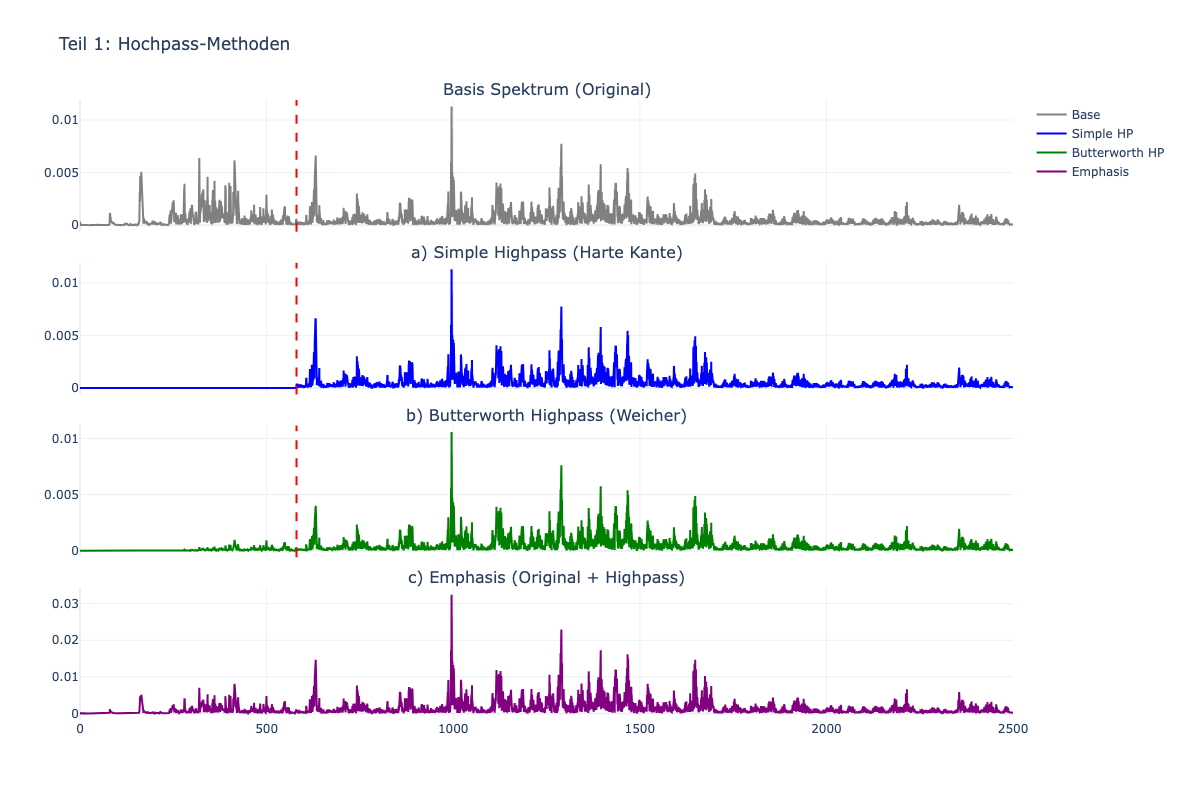

--- Audio Beispiele Teil 1 ---
a) Simple Highpass (Klingt oft künstlich/klickend wegen harter Kante):


b) Butterworth Highpass (Natürlicher):


c) Emphasis (Brillanter):


In [6]:
# Wir zoomen auf den interessanten Bereich (0 bis 2000 Hz),
# da Audio bis 4kHz geht, aber der Gong tief ist.
mask_plot = (freqs >= 0) & (freqs < 2500)
f_plot = freqs[mask_plot]

fig1 = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=(
        "Basis Spektrum (Original)",
        "a) Simple Highpass (Harte Kante)",
        "b) Butterworth Highpass (Weicher)",
        "c) Emphasis (Original + Highpass)",
    ),
)

# Plot 1: Base
fig1.add_trace(
    go.Scatter(
        x=f_plot,
        y=np.abs(y_fft_shifted)[mask_plot],
        name="Base",
        line=dict(color="gray"),
    ),
    row=1,
    col=1,
)
# Markiere Cutoff
fig1.add_vline(x=w_c, line_dash="dash", line_color="red", row=1, col=1)

# Plot 2: Simple HP
fig1.add_trace(
    go.Scatter(
        x=f_plot,
        y=np.abs(y_simple_hp)[mask_plot],
        name="Simple HP",
        line=dict(color="blue"),
    ),
    row=2,
    col=1,
)
fig1.add_vline(x=w_c, line_dash="dash", line_color="red", row=2, col=1)

# Plot 3: Butterworth HP
fig1.add_trace(
    go.Scatter(
        x=f_plot,
        y=np.abs(y_bw_hp)[mask_plot],
        name="Butterworth HP",
        line=dict(color="green"),
    ),
    row=3,
    col=1,
)
fig1.add_vline(x=w_c, line_dash="dash", line_color="red", row=3, col=1)

# Plot 4: Emphasis
fig1.add_trace(
    go.Scatter(
        x=f_plot,
        y=np.abs(y_emph)[mask_plot],
        name="Emphasis",
        line=dict(color="purple"),
    ),
    row=4,
    col=1,
)

fig1.update_layout(
    height=800, title="Teil 1: Hochpass-Methoden", template="plotly_white"
)
fig1.show()

# Audio Player Teil 1
print("--- Audio Beispiele Teil 1 ---")
print("a) Simple Highpass (Klingt oft künstlich/klickend wegen harter Kante):")
display(Audio(sig_simple, rate=fs))

print("b) Butterworth Highpass (Natürlicher):")
display(Audio(sig_bw, rate=fs))

print("c) Emphasis (Brillanter):")
display(Audio(sig_emph, rate=fs))

## Visualisierung (d - TP Subtraktion)

In [7]:
fig2 = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        "Basis Spektrum",
        "Tiefpass (wird abgezogen)",
        "Quasi-Hochpass (Original - TP)",
    ),
)

# Plot 1: Base
fig2.add_trace(
    go.Scatter(
        x=f_plot,
        y=np.abs(y_fft_shifted)[mask_plot],
        name="Base",
        line=dict(color="gray"),
    ),
    row=1,
    col=1,
)

# Plot 2: Tiefpass
fig2.add_trace(
    go.Scatter(
        x=f_plot, y=np.abs(y_tp)[mask_plot], name="Tiefpass", line=dict(color="orange")
    ),
    row=2,
    col=1,
)
fig2.add_vline(x=w_c, line_dash="dash", line_color="red", row=2, col=1)

# Plot 3: Resultat (Quasi HP)
fig2.add_trace(
    go.Scatter(
        x=f_plot,
        y=np.abs(y_quasi_hp)[mask_plot],
        name="Ergebnis",
        line=dict(color="teal"),
    ),
    row=3,
    col=1,
)
fig2.add_vline(x=w_c, line_dash="dash", line_color="red", row=3, col=1)

fig2.update_layout(
    height=600, title="Teil 2: Komplementäre Filterung", template="plotly_white"
)
fig2.show()

print("--- Audio Beispiele Teil 2 ---")
print("d) Quasi Highpass (via Subtraktion):")
display(Audio(sig_quasi_hp, rate=fs))

--- Audio Beispiele Teil 2 ---
d) Quasi Highpass (via Subtraktion):
